In [1]:
!pip install numpy pandas scipy scikit-learn torch matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
DATA_PATH = r'C:/Users/SPAC6/Desktop/python data/data/'
import os; os.makedirs(r'C:/Users/SPAC6/Desktop/python data/형민/save/CNN/', exist_ok=True)
print('DATA_PATH:', DATA_PATH)

DATA_PATH: C:/Users/SPAC6/Desktop/python data/data/


In [4]:
sensor1 = pd.read_csv(DATA_PATH + 'g1_sensor1.csv', names = ['time', 'normal', 'type1', 'type2', 'type3'])
sensor2 = pd.read_csv(DATA_PATH + 'g1_sensor2.csv', names = ['time', 'normal', 'type1', 'type2', 'type3'])
sensor3 = pd.read_csv(DATA_PATH + 'g1_sensor3.csv', names = ['time', 'normal', 'type1', 'type2', 'type3'])
sensor4 = pd.read_csv(DATA_PATH + 'g1_sensor4.csv', names = ['time', 'normal', 'type1', 'type2', 'type3'])

In [5]:
sensor1

,time,normal,type1,type2,type3
0,0.000000,-0.853307,-3.464579,0.555219,3.919664
1,0.000736,-0.740463,-2.448986,-0.234687,4.145351
2,0.001472,-0.138630,-1.922383,-0.009000,2.941685
3,0.002208,0.049443,-0.906790,-0.272301,2.603155
4,0.002944,-0.289088,-0.568259,-0.986978,1.361874
...,...,...,...,...,...
190213,139.996768,-1.156354,-2.696750,0.844491,-2.109427
190214,139.997504,-0.930666,-1.380241,0.919720,-2.222270
190215,139.998240,-0.554521,-2.132532,0.731647,-2.109427
190216,139.998976,-1.419655,-2.433448,1.183022,-3.087405


In [6]:
print('sensor 1의 데이터 크기', sensor1.shape)
print('sensor 2의 데이터 크기', sensor2.shape)
print('sensor 3의 데이터 크기', sensor3.shape)
print('sensor 4의 데이터 크기', sensor4.shape)

sensor 1의 데이터 크기 (190218, 5)
sensor 2의 데이터 크기 (184211, 5)
sensor 3의 데이터 크기 (196079, 5)
sensor 4의 데이터 크기 (183969, 5)


In [7]:
from scipy import interpolate
x_new = np.arange(0, 140, 0.001)
y_new1 = []; y_new2 = []; y_new3 = []; y_new4 = []
for item in ['normal', 'type1', 'type2', 'type3']:
    f_linear1 = interpolate.interp1d(sensor1['time'], sensor1[item], kind='linear');
    y_new1.append(f_linear1(x_new))
    f_linear2 = interpolate.interp1d(sensor2['time'], sensor2[item], kind='linear');
    y_new2.append(f_linear2(x_new))
    f_linear3 = interpolate.interp1d(sensor3['time'], sensor3[item], kind='linear');
    y_new3.append(f_linear3(x_new))
    f_linear4 = interpolate.interp1d(sensor4['time'], sensor4[item], kind='linear');
    y_new4.append(f_linear4(x_new))

sensor1 = pd.DataFrame(np.array(y_new1).T, columns = ['normal', 'type1', 'type2', 'type3'])
sensor2 = pd.DataFrame(np.array(y_new2).T, columns = ['normal', 'type1', 'type2', 'type3'])
sensor3 = pd.DataFrame(np.array(y_new3).T, columns = ['normal', 'type1', 'type2', 'type3'])
sensor4 = pd.DataFrame(np.array(y_new4).T, columns = ['normal', 'type1', 'type2', 'type3'])

In [8]:
sensor1

,normal,type1,type2,type3
0,-0.853307,-3.464579,0.555219,3.919664
1,-0.524588,-2.260096,-0.153734,3.713601
2,-0.003708,-1.193805,-0.197890,2.698827
3,-0.297674,-0.490986,-0.972668,1.338978
4,-0.091203,0.790771,-0.913384,0.701167
...,...,...,...,...
139995,-1.057411,-1.389236,0.664186,-1.498190
139996,-0.513635,-1.368793,1.050553,-0.982626
139997,-1.085213,-2.281763,0.868204,-2.144997
139998,-0.677177,-1.887220,0.792975,-2.146224


In [9]:
normal_ = pd.concat([sensor1['normal'], sensor2['normal'], sensor3['normal'],
sensor4['normal']], axis=1)
type1_ = pd.concat([sensor1['type1'], sensor2['type1'], sensor3['type1'],
sensor4['type1']], axis=1)
type2_ = pd.concat([sensor1['type2'], sensor2['type2'], sensor3['type2'],
sensor4['type2']], axis=1)
type3_ = pd.concat([sensor1['type3'], sensor2['type3'], sensor3['type3'],
sensor4['type3']], axis=1)
normal_.columns = ['s1', 's2', 's3', 's4']; type1_.columns = ['s1', 's2', 's3', 's4']
type2_.columns = ['s1', 's2', 's3', 's4']; type3_.columns = ['s1', 's2', 's3', 's4']

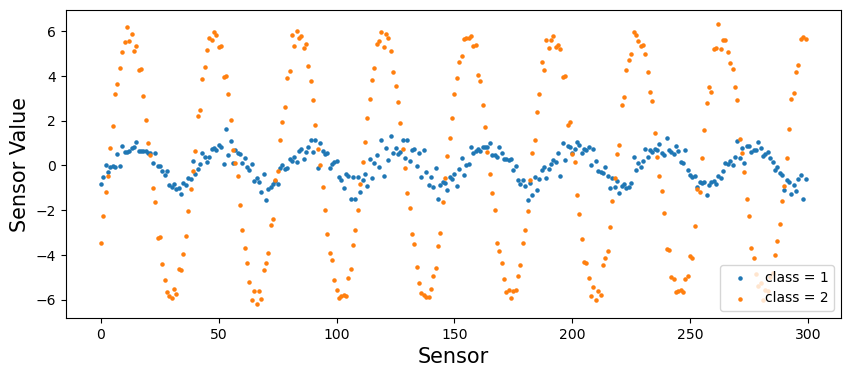

In [10]:
plt.figure(figsize = (10, 4))
plt.scatter(range(0,300), normal_['s1'][:300], label="class = "+str(1), marker='o', s=5)
plt.scatter(range(0,300), type1_['s1'][:300], label="class = "+str(2), marker='o', s=5)

plt.legend(loc="lower right")
plt.xlabel("Sensor", fontsize=15)
plt.ylabel("Sensor Value", fontsize=15)
plt.show()
plt.close()

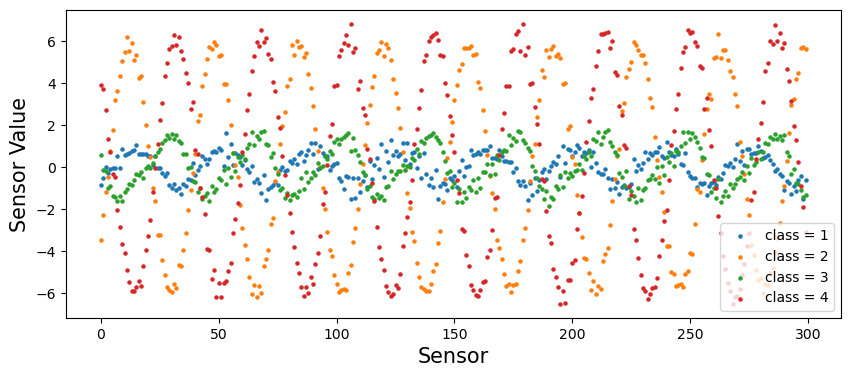

In [11]:
plt.figure(figsize = (10, 4))
plt.scatter(range(0,300), normal_['s1'][:300], label="class = "+str(1), marker='o', s=5)
plt.scatter(range(0,300), type1_['s1'][:300], label="class = "+str(2), marker='o', s=5)
plt.scatter(range(0,300), type2_['s1'][:300], label="class = "+str(3), marker='o', s=5)
plt.scatter(range(0,300), type3_['s1'][:300], label="class = "+str(4), marker='o', s=5)

plt.legend(loc="lower right")
plt.xlabel("Sensor", fontsize=15)
plt.ylabel("Sensor Value", fontsize=15)
plt.show()
plt.close()

In [12]:
print('sensor 1의 데이터 크기', sensor1.shape)
print('sensor 2의 데이터 크기', sensor2.shape)
print('sensor 3의 데이터 크기', sensor3.shape)
print('sensor 4의 데이터 크기', sensor4.shape)

sensor 1의 데이터 크기 (140000, 4)
sensor 2의 데이터 크기 (140000, 4)
sensor 3의 데이터 크기 (140000, 4)
sensor 4의 데이터 크기 (140000, 4)


In [13]:
normal_.corr()

,s1,s2,s3,s4
s1,1.000000,-0.007093,0.004297,-0.003377
s2,-0.007093,1.000000,-0.002992,0.111121
s3,0.004297,-0.002992,1.000000,-0.006434
s4,-0.003377,0.111121,-0.006434,1.000000


<Axes: >

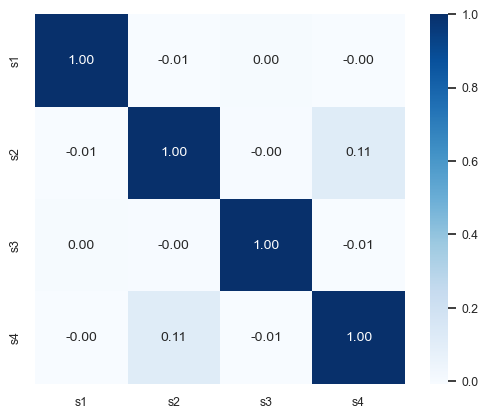

In [14]:
names = ['s1','s2','s3','s4']
cm = np.corrcoef(normal_[names].values.T)
sns.set(font_scale=0.8)
sns.heatmap(cm, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
yticklabels=names, xticklabels=names, cmap=plt.cm.Blues)

In [15]:
M = 15

# 1. Normal 데이터 필터링 및 형태 변환
normal_s1 = np.convolve(normal_['s1'], np.ones(M), 'valid') / M
normal_s1 = normal_s1.reshape(len(normal_s1), 1)

normal_s2 = np.convolve(normal_['s2'], np.ones(M), 'valid') / M
normal_s2 = normal_s2.reshape(len(normal_s2), 1)

normal_s3 = np.convolve(normal_['s3'], np.ones(M), 'valid') / M
normal_s3 = normal_s3.reshape(len(normal_s3), 1)

normal_s4 = np.convolve(normal_['s4'], np.ones(M), 'valid') / M
normal_s4 = normal_s4.reshape(len(normal_s4), 1)

# 2. Type1 데이터 필터링 및 형태 변환
type1_s1 = np.convolve(type1_['s1'], np.ones(M), 'valid') / M
type1_s1 = type1_s1.reshape(len(type1_s1), 1)

type1_s2 = np.convolve(type1_['s2'], np.ones(M), 'valid') / M
type1_s2 = type1_s2.reshape(len(type1_s2), 1)

type1_s3 = np.convolve(type1_['s3'], np.ones(M), 'valid') / M
type1_s3 = type1_s3.reshape(len(type1_s3), 1)

type1_s4 = np.convolve(type1_['s4'], np.ones(M), 'valid') / M
type1_s4 = type1_s4.reshape(len(type1_s4), 1)

# 3. Type2 데이터 필터링 및 형태 변환
type2_s1 = np.convolve(type2_['s1'], np.ones(M), 'valid') / M
type2_s1 = type2_s1.reshape(len(type2_s1), 1)

type2_s2 = np.convolve(type2_['s2'], np.ones(M), 'valid') / M
type2_s2 = type2_s2.reshape(len(type2_s2), 1)

type2_s3 = np.convolve(type2_['s3'], np.ones(M), 'valid') / M
type2_s3 = type2_s3.reshape(len(type2_s3), 1)

type2_s4 = np.convolve(type2_['s4'], np.ones(M), 'valid') / M
type2_s4 = type2_s4.reshape(len(type2_s4), 1)

# 4. Type3 데이터 필터링 및 형태 변환
type3_s1 = np.convolve(type3_['s1'], np.ones(M), 'valid') / M
type3_s1 = type3_s1.reshape(len(type3_s1), 1)

type3_s2 = np.convolve(type3_['s2'], np.ones(M), 'valid') / M
type3_s2 = type3_s2.reshape(len(type3_s2), 1)

type3_s3 = np.convolve(type3_['s3'], np.ones(M), 'valid') / M
type3_s3 = type3_s3.reshape(len(type3_s3), 1)

type3_s4 = np.convolve(type3_['s4'], np.ones(M), 'valid') / M
type3_s4 = type3_s4.reshape(len(type3_s4), 1)

# 5. 데이터 합치기 (Concatenate)
normal_temp = np.concatenate((normal_s1, normal_s2, normal_s3, normal_s4), axis=1)
type1_temp = np.concatenate((type1_s1, type1_s2, type1_s3, type1_s4), axis=1)
type2_temp = np.concatenate((type2_s1, type2_s2, type2_s3, type2_s4), axis=1)
type3_temp = np.concatenate((type3_s1, type3_s2, type3_s3, type3_s4), axis=1)

print("데이터 전처리가 완료되었습니다.")
print("normal_temp shape:", normal_temp.shape)

데이터 전처리가 완료되었습니다.
normal_temp shape: (139986, 4)


In [16]:
normal_

,s1,s2,s3,s4
0,-0.853307,0.048823,-0.437626,-1.116226
1,-0.524588,-0.029477,-0.149817,-0.659694
2,-0.003708,-0.004751,0.280889,-0.857345
3,-0.297674,0.009673,-0.303281,-0.685318
4,-0.091203,0.096215,-0.320263,-0.303108
...,...,...,...,...
139995,-1.057411,0.587429,0.275044,0.289837
139996,-0.513635,-0.137874,-0.045973,0.131462
139997,-1.085213,0.002242,-0.164593,-0.087380
139998,-0.677177,-0.308897,0.288252,1.319862


In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(normal_)
normal = scaler.transform(normal_temp)
type1 = scaler.transform(type1_temp)
type2 = scaler.transform(type2_temp)
type3 = scaler.transform(type3_temp)
print("데이터 정규화가 완료되었습니다.")

데이터 정규화가 완료되었습니다.


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [18]:
print(normal)
print('------------------------------------------------')
print('normal data size = ', normal.shape)

[[0.57598822 0.50553898 0.56439491 0.44551164]
 [0.60960317 0.50513674 0.58169332 0.44848001]
 [0.62990663 0.5047345  0.59547186 0.46260474]
 ...
 [0.51874981 0.50106998 0.60999194 0.50715712]
 [0.49713039 0.51588928 0.6074125  0.53093987]
 [0.45708747 0.52025039 0.60349765 0.53976513]]
------------------------------------------------
normal data size =  (139986, 4)


In [19]:
normal

array([[0.57598822, 0.50553898, 0.56439491, 0.44551164],
       [0.60960317, 0.50513674, 0.58169332, 0.44848001],
       [0.62990663, 0.5047345 , 0.59547186, 0.46260474],
       ...,
       [0.51874981, 0.50106998, 0.60999194, 0.50715712],
       [0.49713039, 0.51588928, 0.6074125 , 0.53093987],
       [0.45708747, 0.52025039, 0.60349765, 0.53976513]],
      shape=(139986, 4))

In [20]:
normal = normal[30000:130000][:]
type1 = type1[30000:130000][:]
type2 = type2[30000:130000][:]
type3 = type3[30000:130000][:]
print(normal)
print('------------------------------------------------')
print('normal data size = ', normal.shape)

[[0.42588581 0.56360116 0.59076635 0.45259554]
 [0.39980512 0.54859132 0.57699856 0.4486034 ]
 [0.38031149 0.54190146 0.57998374 0.44726771]
 ...
 [0.48028648 0.53048363 0.62114742 0.51024851]
 [0.44818273 0.53444251 0.62103995 0.49126006]
 [0.42832757 0.5501298  0.60917718 0.47827626]]
------------------------------------------------
normal data size =  (100000, 4)


In [21]:
# 데이터 분배 (슬라이싱)
# [:][:60000]의 의미: 전체 데이터 중에서 처음부터 6만 개까지 자른다는 뜻
normal_train = normal[:][:60000]; normal_valid = normal[:][60000:80000]; normal_test = normal[:][80000:]
type1_train = type1[:][:60000]; type1_valid = type1[:][60000:80000]; type1_test = type1[:][80000:]
type2_train = type2[:][:60000]; type2_valid = type2[:][60000:80000]; type2_test = type2[:][80000:]
type3_train = type3[:][:60000]; type3_valid = type3[:][60000:80000]; type3_test = type3[:][80000:]

# 데이터 합치기 (Concatenate)
# 나눠놓은 조각들을 용도별(학습용, 검증용, 시험용)로 한데 모으는 과정
train = np.concatenate((normal_train, type1_train, type2_train, type3_train))
valid = np.concatenate((normal_valid, type1_valid, type2_valid, type3_valid))
test = np.concatenate((normal_test, type1_test, type2_test, type3_test))

# 형태 출력 
print("train data의 형태:", train.shape)
print("valid data의 형태:", valid.shape)
print(" test data의 형태:", test.shape)

train data의 형태: (240000, 4)
valid data의 형태: (80000, 4)
 test data의 형태: (80000, 4)


In [22]:
train_label = np.concatenate((np.full((60000,1),0), np.full((60000,1),1),
np.full((60000,1),2), np.full((60000,1),3)))
valid_label = np.concatenate((np.full((20000,1),0), np.full((20000,1),1),
np.full((20000,1),2), np.full((20000,1),3)))
test_label = np.concatenate((np.full((20000,1),0), np.full((20000,1),1),
np.full((20000,1),2), np.full((20000,1),3)))
print("데이터 라벨링 완료")

데이터 라벨링 완료


In [23]:
idx = np.arange(train.shape[0]); np.random.shuffle(idx);
train = train[:][idx]; train_label = train_label[:][idx]
idx_v = np.arange(valid.shape[0]); np.random.shuffle(idx_v);
valid = valid[:][idx_v]; valid_label = valid_label[:][idx_v]
idx_t = np.arange(test.shape[0]); np.random.shuffle(idx_t);
test = test[:][idx_t]; test_label = test_label[:][idx_t]
print("데이터 뒤섞기 완료")

데이터 뒤섞기 완료


In [24]:
x_train = torch.from_numpy(train).float()
y_train = torch.from_numpy(train_label).float().T[0]
x_valid = torch.from_numpy(valid).float()
y_valid = torch.from_numpy(valid_label).float().T[0]
x_test = torch.from_numpy(test).float()
y_test = torch.from_numpy(test_label).float().T[0]
print("변경 전")
train

변경 전


array([[0.68836092, 0.4642874 , 0.61676466, 0.59113979],
       [0.91343635, 0.36015391, 0.55996515, 0.43863315],
       [0.66038236, 0.42605853, 0.56051389, 0.49496402],
       ...,
       [0.35554464, 0.53711174, 0.55718586, 0.4980865 ],
       [0.28182591, 0.36254808, 0.53652747, 0.53225532],
       [0.95442822, 0.31511509, 0.61831184, 0.52459279]],
      shape=(240000, 4))

In [25]:
print("변경 후")
x_train

변경 후


tensor([[0.6884, 0.4643, 0.6168, 0.5911],
        [0.9134, 0.3602, 0.5600, 0.4386],
        [0.6604, 0.4261, 0.5605, 0.4950],
        ...,
        [0.3555, 0.5371, 0.5572, 0.4981],
        [0.2818, 0.3625, 0.5365, 0.5323],
        [0.9544, 0.3151, 0.6183, 0.5246]])

In [26]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
train = TensorDataset(x_train, y_train)
train_dataloader = DataLoader(train, batch_size =5000, shuffle=True)
valid = TensorDataset(x_valid, y_valid)
valid_dataloader = DataLoader(valid, batch_size =len(x_valid), shuffle=False)
test = TensorDataset(x_test, y_test)
test_dataloader = DataLoader(test, batch_size =len(x_valid), shuffle=False)

In [27]:
import torch          
import torch.nn as nn
class KAMP_CNN(nn.Module):
    def __init__(self):
        # 1. 클래스 초기화 (Tab 2번)
        super(KAMP_CNN, self).__init__()
        
        # 2. 첫 번째 주방 세팅
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=100, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=1, stride=1),
            nn.Dropout(p=0.2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=100, out_channels=100, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=1, stride=1),
            nn.Dropout(p=0.2))

        self.conv3 = nn.Sequential(
            nn.Conv1d(in_channels=100, out_channels=100, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=1, stride=1),
            nn.Dropout(p=0.2))
        
        # 3. 마지막 주방 세팅
        self.conv4 = nn.Sequential(
            nn.Conv1d(in_channels=100, out_channels=4, kernel_size=2, stride=1, padding='same'),
            nn.BatchNorm1d(4),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=1, stride=1)
        )
        
 # 4. 최종 결론 판사석 세팅
        self.final_pool = nn.AdaptiveAvgPool1d(1)
        self.linear = nn.Linear(4, 4)

    def forward(self, input):
        # 데이터가 흘러가는 순서 (Tab 2번)
        input = input.unsqueeze(1)
        out = self.conv1(input)
        out = self.conv2(out)
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.final_pool(out)
        out = self.linear(out.squeeze(-1))
        
        return out

# 모델 생성 및 확인 (들여쓰기 없음)
model_check = KAMP_CNN()
print(model_check)
        
# 2. 가짜 손님(데이터) 1명 만들기: 센서값 4개를 가진 임의의 데이터
dummy_input = torch.randn(1, 4)

# 3. ⭐️ 드디어 손님 입장! ⭐️ (이 코드가 forward 함수를 작동시킵니다!)
print("=== 식당 문 엽니다! 데이터 들어갑니다! ===")
result = model_check(dummy_input)       

KAMP_CNN(
  (conv1): Sequential(
    (0): Conv1d(1, 100, kernel_size=(2,), stride=(1,), padding=same)
    (1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv1d(100, 100, kernel_size=(2,), stride=(1,), padding=same)
    (1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv1d(100, 100, kernel_size=(2,), stride=(1,), padding=same)
    (1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (conv4): 

C:\Users\SPAC6\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1026.)
  return F.conv1d(


In [28]:
import torch # 누락 방지

def train_model(model, criterion, optimizer, num_epochs, train_dataloader, PATH):
    # (오타 수정: 함수 괄호 안의 num_epoch를 아래 for문과 똑같이 num_epochs로 맞췄습니다)
    
    loss_values = []
    loss_values_v = []
    check = 0
    accuracy_past = 0
    
    # 1. 100번(num_epochs)의 지옥 훈련 시작
    for epoch in range(1, num_epochs + 1):
        
        # ---------------------- 모델 학습 --------------------- #
        model.train()
        batch_number = 0
        running_loss = 0.0
        
        # 훈련용 데이터를 미니배치 단위로 불러오기
        for batch_idx, samples in enumerate(train_dataloader):
            x_train, y_train = samples
            
            # 파이토치 학습 5단계 콤보
            optimizer.zero_grad()                      # 기울기 초기화
            y_hat = model.forward(x_train)             # 순전파 (Forward)
            loss = criterion(y_hat, y_train.long())    #  손실 계산
            loss.backward()                            #  역전파 (Backward)
            optimizer.step()                           #  가중치 갱신

            
            running_loss += loss.item()
            batch_number += 1
            
        # 한 에폭(하루 훈련)이 끝날 때마다 평균 오차 기록
        loss_values.append(running_loss / batch_number)
        
        # ---------------------- 모델 검증 --------------------- #
        model.eval()
        accuracy = 0.0
        total = 0.0
        
        # 검증용 데이터로 모의고사 보기
        for batch_idx, data in enumerate(valid_dataloader):
            x_valid, y_valid = data
            v_hat = model.forward(x_valid)
            v_loss = criterion(v_hat, y_valid.long())
            
            _, predicted = torch.max(v_hat.data, 1)
            total += y_valid.size(0)
            accuracy += (predicted == y_valid).sum().item()
            
        # 🚨 가이드북의 논리적 버그 수정 완료 (loss.item() -> v_loss.item())
        loss_values_v.append(v_loss.item())
        accuracy = (accuracy / total)
        
        # ---------------- Check for early stopping --------------- #
        if epoch % 1 == 0:
            print('[Epoch {}/{}] [Train_Loss: {:.6f} / Valid_Loss: {:.6f}]'.format(epoch, num_epochs, loss.item(), v_loss.item()))
            print('[Epoch {}/{}] [Accuracy : {:.6f}]'.format(epoch, num_epochs, accuracy))
            
        # 정확도가 안 오르고 떨어지는지 감시
        if accuracy_past > accuracy:
            check += 1
        else:
            check = 0
            accuracy_past = accuracy
            
        # 50번 연속으로 성능이 떨어지면 강제 종료 (조기 종료)
        if check > 50:
            print('This is time to do early stopping (조기 종료 발동!)')
            torch.save(model, PATH + 'model.pt')
            return loss_values, loss_values_v # 여기서 훈련 끝내고 기록 반환!
            
    # 조기 종료 없이 100번 훈련을 무사히 마쳤을 때의 최종 저장 및 반환
    torch.save(model, PATH + 'model.pt')
    return loss_values, loss_values_v
print("학습준비완료")

학습준비완료


In [ ]:
import os
import time        
import torch         
import torch.nn as nn 

CNN_model = KAMP_CNN()
num_epochs =100
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CNN_model.parameters())
PATH = r'C:/Users/SPAC6/Desktop/python data/save/CNN/'

#"만약 save/CNN/ 폴더가 없으면 에러 내지 말고 니가 만들어!"
os.makedirs(PATH, exist_ok=True)

# 계산 시간 측정 시작 (t_start)
start_time = time.time()

CNN_loss_values, CNN_loss_values_v = train_model(CNN_model, criterion, optimizer,
num_epochs, train_dataloader, PATH)

# 계산 시간 측정 종료 및 산출 (t_end - t_start)
end_time = time.time()
train_duration = end_time - start_time
print(f'1D-CNN Training Computation Time: {train_duration:.4f} seconds')

In [30]:
def test_model(model, PATH):
    model = torch.load(PATH +'model.pt')
    #---------------------- 모델 시험 ---------------------#
    model.eval()
    total = 0.0
    accuracy = 0.0
    
    for batch_idx, data in enumerate(test_dataloader):
        # for문 안쪽은 무조건 4칸(Tab) 들여쓰기를 해야 합니다.
        x_test, y_test = data

        t_hat = model(x_test)
        _, predicted = torch.max(t_hat.data, 1)
        total += y_test.size(0)
        accuracy += (predicted == y_test).sum().item()
        accuracy = (accuracy / total)
        
    #------------------------------------------------------#
    print(accuracy)
    print("CNN모델평가완료")

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

def draw_confusion_matrix(model, xt, yt, PATH):
    y_pred = []; y_true = []
    model.eval()
    
    y_hat = model(xt); output = (torch.max(torch.exp(y_hat), 1)[1]).data.cpu().numpy()
    y_pred.extend(output)
    
    labels = y_test.data.cpu().numpy()
    y_true.extend(labels)
    
    # 분류 항목
    classes = ('Normal', 'Type1', 'Type2', 'Type3')
    
    # Confussion Matrix 생성
    plt.figure(figsize = (7,5))
    dlen = float(len(x_test)) # test data 크기 : 여기서는 80000
    cm = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm/dlen, index = [i for i in classes], columns = [i for i in classes])
    
    sns.heatmap(df_cm, annot=True, cmap=plt.cm.Blues)
    plt.title("Confusion Matrix", size=24, fontweight='bold')
    plt.xlabel("Predicted Label", size=16); plt.ylabel("Actual Label", size=16)
    
    # 잘려나갔던 코드 완벽 복원 및 들여쓰기 완료
    plt.rc('xtick', labelsize=12); plt.rc('ytick', labelsize=12); plt.yticks(rotation=0)
    plt.savefig(PATH +'cm_output.png')

In [32]:
def plot_loss_graph(loss_values, loss_values_v):
    plt.figure()
    plt.plot(loss_values)
    plt.plot(loss_values_v)
    plt.title("Training & Validation Loss")
    plt.ylabel("loss", fontsize="large")
    plt.xlabel("epoch", fontsize="large")
    plt.legend(["train", "validation"])
    plt.tight_layout()
    
    # 결과 저장
    plt.savefig(PATH +'lossplot_output.png')

In [ ]:
PATH = r'C:/Users/SPAC6/Desktop/python data/save/'
test_model(CNN_model, PATH)

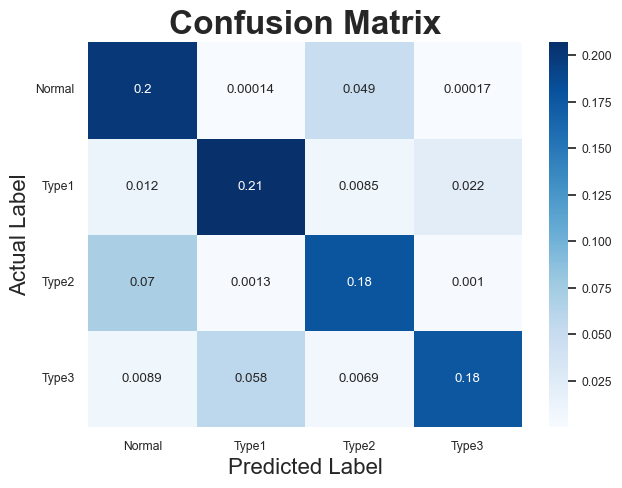

In [34]:
draw_confusion_matrix(CNN_model, x_test, y_test, PATH)

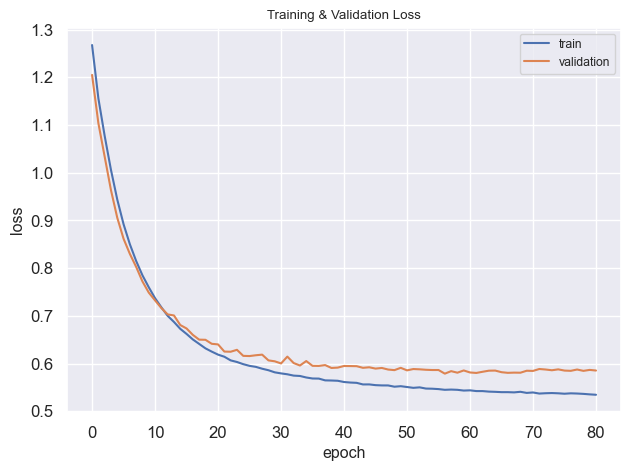

In [35]:
plot_loss_graph(CNN_loss_values, CNN_loss_values_v)